# Research Day Metrics Notebook

Fresh notebook. Fresh cells. One chart at a time.

What you get:
- clean tables
- seaborn graphs
- simple notes after every chart
- drone benchmark at the end


In [1]:
from pathlib import Path
import html as html_lib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython import get_ipython
    from IPython.display import HTML, Markdown, display
except ModuleNotFoundError:
    def get_ipython():
        return None

    class HTML(str):
        pass

    class Markdown(str):
        pass

    def display(obj):
        print(obj)

BG = '#f6f3ee'
INK = '#1f2937'
MUTED = '#6b7280'
GRID = '#ddd5c9'
BLUE = '#2f6690'
GREEN = '#2d936c'
AMBER = '#d17b0f'
RED = '#b33f62'
TEAL = '#4c8c84'
NAVY = '#24415d'

sns.set_theme(style='whitegrid', context='talk')
sns.set_palette([BLUE, GREEN, AMBER, RED, TEAL, NAVY])
pd.options.display.float_format = '{:.4f}'.format

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': 'white',
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.color': INK,
    'ytick.color': INK,
    'font.size': 11,
    'grid.color': GRID,
    'grid.alpha': 0.30,
    'figure.max_open_warning': 0,
})

try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

def find_packet_root(start=None):
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'research_day_packet' / 'source_reports').exists():
            return path / 'research_day_packet'
        if (path / 'source_reports').exists() and (path / 'metrics').exists():
            return path
    raise FileNotFoundError('Could not find research_day_packet from the current working directory.')

PACKET_ROOT = find_packet_root()
SOURCE = PACKET_ROOT / 'source_reports'
REPO_ROOT = PACKET_ROOT.parent

def load_json(name):
    return json.loads((SOURCE / name).read_text())

def parse_markdown_table(path):
    rows = []
    header = None
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line.startswith('|'):
            continue
        parts = [cell.strip() for cell in line.strip('|').split('|')]
        if not parts or set(''.join(parts)) <= {'-', ':'}:
            continue
        if header is None:
            header = parts
            continue
        rows.append(parts)
    frame = pd.DataFrame(rows, columns=header)
    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors='ignore')
    return frame

def style_axis(ax, title, ylabel='', xlabel=''):
    ax.set_title(title, loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK)
    ax.grid(axis='y', color=GRID, alpha=0.30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)

def label_bars(ax, bars, fmt='{:.3f}'):
    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * 0.02 if ymax > ymin else 0.05
    for bar in bars:
        height = bar.get_height()
        if not np.isfinite(height):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + pad,
            fmt.format(height),
            ha='center',
            va='bottom',
            fontsize=9.2,
            color=INK,
            clip_on=False,
        )

def gaussian_pdf(x, mu, sigma):
    sigma = float(sigma)
    if sigma <= 1e-9:
        return np.zeros_like(x, dtype=float)
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) ** 2) / (sigma ** 2))

def confusion_matrix_from_dict(cm):
    return np.array([[cm['tp'], cm['fn']], [cm['fp'], cm['tn']]])

def draw_confusion(ax, cm, title, cmap='YlGnBu'):
    matrix = confusion_matrix_from_dict(cm)
    ax.imshow(matrix, cmap=cmap)
    ax.set_title(title, loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted +', 'Predicted -'])
    ax.set_yticklabels(['Actual +', 'Actual -'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center', fontsize=11, fontweight='bold', color=INK)
    for spine in ax.spines.values():
        spine.set_color(GRID)

def is_positive(label):
    return str(label).strip().lower() not in {'noncar', 'negative', 'background', 'none'}

def resolve_asset(path_str):
    path = Path(path_str)
    cleaned = str(path).lstrip('./')
    candidates = []
    if path.is_absolute():
        candidates.append(path)
    candidates.extend([
        REPO_ROOT / cleaned,
        PACKET_ROOT / cleaned,
        SOURCE / cleaned,
        SOURCE.parent / cleaned,
        REPO_ROOT / 'backend' / cleaned,
        REPO_ROOT / 'backend' / path.name,
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]

def format_cell(column, value):
    if pd.isna(value):
        return ''
    if isinstance(value, str):
        return html_lib.escape(value)
    label = str(column).lower()
    if 'latency' in label or 'runtime' in label:
        return f'{value:,.1f}'
    if any(key in label for key in ['precision', 'recall', 'accuracy', 'specificity', 'confidence', 'miss', 'false alarm']) or str(column) in {'F1', 'IoU'}:
        return f'{value:.3f}'
    if any(key in label for key in ['sample', 'count', 'pixels', 'components', 'instances']) or str(column) in {'TP', 'FN', 'FP', 'TN'}:
        return f'{int(value)}'
    return f'{value}'

def column_theme(column):
    label = str(column).lower()
    theme = {
        'head_bg': '#eef4fb',
        'head_fg': '#24415d',
        'cell_even': '#ffffff',
        'cell_odd': '#f8fbff',
        'edge': '#d8e3ef',
        'align': 'center',
    }
    if label in {'run', 'method label', 'image path', 'mask source', 'output path'}:
        return {
            'head_bg': '#24415d',
            'head_fg': '#ffffff',
            'cell_even': '#f5f7fb',
            'cell_odd': '#edf2f8',
            'edge': '#d6deea',
            'align': 'left',
        }
    if 'latency' in label or 'runtime' in label:
        return {
            'head_bg': '#f8e2bf',
            'head_fg': '#7a4308',
            'cell_even': '#fff7ea',
            'cell_odd': '#fff0d9',
            'edge': '#efd1a3',
            'align': 'center',
        }
    if 'precision' in label or 'specificity' in label:
        return {
            'head_bg': '#dcecf8',
            'head_fg': '#1f4c73',
            'cell_even': '#f4faff',
            'cell_odd': '#eaf5fe',
            'edge': '#c8def0',
            'align': 'center',
        }
    if 'recall' in label or str(column) in {'F1', 'Accuracy', 'TP', 'TN'}:
        return {
            'head_bg': '#dcefe7',
            'head_fg': '#1d5c4a',
            'cell_even': '#f5fcf8',
            'cell_odd': '#ebf8f0',
            'edge': '#c8e3d6',
            'align': 'center',
        }
    if 'miss' in label or 'false alarm' in label or str(column) in {'FN', 'FP'}:
        return {
            'head_bg': '#f8d8dd',
            'head_fg': '#873447',
            'cell_even': '#fff5f7',
            'cell_odd': '#fdecef',
            'edge': '#efc5cd',
            'align': 'center',
        }
    if 'confidence' in label or str(column) == 'IoU':
        return {
            'head_bg': '#d9efee',
            'head_fg': '#1f5f5c',
            'cell_even': '#f3fcfb',
            'cell_odd': '#e8f7f6',
            'edge': '#c5e3e0',
            'align': 'center',
        }
    if 'sample' in label or 'pixels' in label or 'component' in label or 'instance' in label or 'detected positives' in label:
        return {
            'head_bg': '#efe4d4',
            'head_fg': '#6b4f2b',
            'cell_even': '#fcf8f2',
            'cell_odd': '#f7f0e5',
            'edge': '#e4d6bf',
            'align': 'center',
        }
    return theme

def metric_badge(title):
    title_lower = str(title).lower()
    if 'quality' in title_lower or 'result' in title_lower:
        return '#2f6690'
    if 'threshold' in title_lower or 'latency' in title_lower:
        return '#d17b0f'
    if 'benchmark' in title_lower:
        return '#2d936c'
    return '#24415d'

def pretty_table(df, title):
    badge = metric_badge(title)
    headers = ''.join(
        (
            lambda theme, col: (
                f"<th style='padding:11px 13px; border-bottom:1px solid {theme['edge']}; "
                f"background:{theme['head_bg']}; color:{theme['head_fg']}; font-size:12px; "
                f"text-transform:uppercase; letter-spacing:0.05em; text-align:{theme['align']}; "
                f"white-space:nowrap; font-weight:800;'>{html_lib.escape(str(col))}</th>"
            )
        )(column_theme(col), col)
        for col in df.columns
    )
    rows = []
    for idx, row in df.iterrows():
        cells = ''.join(
            (
                lambda theme, col: (
                    f"<td style='padding:12px 13px; border-bottom:1px solid {theme['edge']}; "
                    f"color:#1f2937; background:{theme['cell_even'] if idx % 2 == 0 else theme['cell_odd']}; "
                    f"text-align:{theme['align']}; {'font-weight:700;' if str(col).lower() == 'run' else ''}'>"
                    f"{format_cell(col, row[col])}</td>"
                )
            )(column_theme(col), col)
            for col in df.columns
        )
        rows.append(f'<tr>{cells}</tr>')
    return HTML(
        f"<div style='background:linear-gradient(180deg, #ffffff 0%, #fbfcfe 100%); border:1px solid #d8e3ef; border-radius:18px; padding:14px 16px 18px 16px; margin:10px 0 20px 0; box-shadow:0 12px 28px rgba(36,65,93,0.08); overflow-x:auto;'>"
        f"<div style='display:inline-block; padding:4px 10px; border-radius:999px; background:{badge}; color:white; font-size:11px; font-weight:800; letter-spacing:0.06em; text-transform:uppercase; margin-bottom:8px;'>Table</div>"
        f"<div style='font-size:15px; font-weight:800; color:#1f2937; margin-bottom:12px;'>{html_lib.escape(title)}</div>"
        f"<table style='border-collapse:separate; border-spacing:0; width:100%; min-width:max-content; overflow:hidden; border-radius:14px;'><thead><tr>{headers}</tr></thead><tbody>{''.join(rows)}</tbody></table></div>"
    )

display(Markdown(f'Using saved reports from `{SOURCE}`.'))


Using saved reports from `/Users/deliorincon/SkeletonizationDrones/research_day_packet/source_reports`.

In [2]:
baseline = load_json('strict_evaluation_report_baseline.json')
tuned = load_json('strict_evaluation_report_tuned.json')
benchmark = load_json('benchmark_report.json')
threshold_df = parse_markdown_table(SOURCE / 'threshold_sweep_results.md')

def aggregate_row(run_name, report):
    aggregate = report['aggregate']
    metrics = aggregate['metrics']
    cm = aggregate['confusion_matrix']
    tp = cm['tp']
    fn = cm['fn']
    fp = cm['fp']
    tn = cm['tn']
    return {
        'Run': run_name,
        'Confidence': report['confidence'],
        'IoU': report['iou'],
        'Samples': aggregate['samples'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1': metrics['f1'],
        'Accuracy': metrics['accuracy'],
        'Specificity': tn / (tn + fp) if (tn + fp) else 0.0,
        'Miss Rate': fn / (tp + fn) if (tp + fn) else 0.0,
        'False Alarm Rate': fp / (tn + fp) if (tn + fp) else 0.0,
        'Mean Latency (ms)': aggregate['latency_ms']['mean'],
        'P95 Latency (ms)': aggregate['latency_ms']['p95'],
        'Mean Detection Confidence': aggregate['detection_confidence']['mean'],
        'Detected Positives': aggregate['detection_confidence']['count'],
        'TP': tp,
        'FN': fn,
        'FP': fp,
        'TN': tn,
    }

overview_df = pd.DataFrame([
    aggregate_row('Baseline', baseline),
    aggregate_row('Tuned', tuned),
])

def flatten_details(report, run_name):
    rows = []
    for split_name, split_payload in report['splits'].items():
        for item in split_payload.get('details', []):
            rows.append({
                'Run': run_name,
                'Split': split_name,
                'Image': item['image'],
                'Label': item['label'],
                'Prediction': item['prediction'],
                'Latency (ms)': item['latency_ms'],
                'Best Confidence': item['best_confidence'],
                'Boxes Count': item['boxes_count'],
                'Actual Positive': is_positive(item['label']),
                'Predicted Positive': is_positive(item['prediction']),
            })
    return rows

details_df = pd.DataFrame(flatten_details(baseline, 'Baseline') + flatten_details(tuned, 'Tuned'))
details_df['Outcome'] = np.select(
    [
        details_df['Actual Positive'] & details_df['Predicted Positive'],
        details_df['Actual Positive'] & ~details_df['Predicted Positive'],
        ~details_df['Actual Positive'] & details_df['Predicted Positive'],
    ],
    ['True Positive', 'False Negative', 'False Positive'],
    default='True Negative',
)

outcome_counts_wide_df = overview_df[['Run', 'TP', 'FN', 'FP', 'TN']].copy()

main_results_df = overview_df[['Run', 'Confidence', 'IoU', 'Samples', 'Precision', 'Recall', 'F1', 'Accuracy', 'Mean Latency (ms)', 'P95 Latency (ms)']].copy()
prediction_quality_df = overview_df[['Run', 'Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Miss Rate', 'False Alarm Rate', 'Detected Positives']].copy()

threshold_table_df = threshold_df.copy().sort_values(['f1', 'recall', 'precision'], ascending=False).reset_index(drop=True)
best_threshold_df = threshold_table_df.head(1).copy()

benchmark_input_df = pd.DataFrame([
    {
        'Image Path': benchmark['image_path'],
        'Mask Source': benchmark['mask_source'],
        'YOLO Instances': benchmark['yolo_instances_detected'],
        'Mask Pixels': benchmark['mask_pixels'],
    }
])

benchmark_df = pd.DataFrame([
    {
        'Method Label': method['name'].replace('_', ' ').title(),
        'Runtime (ms)': method['runtime_ms'],
        'Skeleton Pixels': method['skeleton_pixels'],
        'Connected Components': method['connected_components'],
        'Output Path': method['output_path'],
    }
    for method in benchmark['methods']
    if not method.get('error')
]).sort_values('Runtime (ms)').reset_index(drop=True)

preferred_benchmark_candidates = [
    REPO_ROOT / 'hh8v8sig_drone-generic-getty_625x300_02_February_23.webp',
    REPO_ROOT / 'presentation_drone_input.png',
    REPO_ROOT / 'presentation_drone_input.jpg',
    REPO_ROOT / 'presentation_drone_input.jpeg',
]
preferred_benchmark_image = next((path for path in preferred_benchmark_candidates if path.exists()), preferred_benchmark_candidates[1])
active_benchmark_image = preferred_benchmark_image if preferred_benchmark_image.exists() else resolve_asset(benchmark['image_path'])
plain_drone_image = preferred_benchmark_image
if not plain_drone_image.exists():
    fallback_plain_drone = REPO_ROOT / 'backend' / '.venv' / 'lib' / 'python3.12' / 'site-packages' / 'caer' / 'data' / 'drone.jpg'
    plain_drone_image = fallback_plain_drone if fallback_plain_drone.exists() else active_benchmark_image
benchmark_mask_path = str(Path(benchmark['methods'][0]['output_path']).with_name('foreground_mask.png')) if len(benchmark_df) else ''

kpi_plot_df = overview_df.melt(
    id_vars='Run',
    value_vars=['Precision', 'Recall', 'F1', 'Accuracy'],
    var_name='Metric',
    value_name='Score',
)

latency_plot_df = overview_df.melt(
    id_vars='Run',
    value_vars=['Mean Latency (ms)', 'P95 Latency (ms)'],
    var_name='Metric',
    value_name='Milliseconds',
)
latency_plot_df['Metric'] = latency_plot_df['Metric'].map({
    'Mean Latency (ms)': 'Mean',
    'P95 Latency (ms)': 'P95',
})

prediction_metric_plot_df = overview_df.melt(
    id_vars='Run',
    value_vars=['Recall', 'Precision', 'F1', 'Accuracy', 'Specificity'],
    var_name='Metric',
    value_name='Score',
)

confidence_plot_df = overview_df[['Run', 'Mean Detection Confidence']].copy()
positive_count_df = overview_df[['Run', 'Detected Positives']].copy()

outcome_plot_df = overview_df.melt(
    id_vars='Run',
    value_vars=['TP', 'FN', 'FP', 'TN'],
    var_name='Outcome',
    value_name='Count',
)

positive_conf_df = details_df[details_df['Actual Positive']].copy()

display(Markdown(f'Loaded `{len(details_df):,}` per-image rows and `{len(benchmark_df)}` benchmark methods.'))


/var/folders/sz/003snp_514d8b77g7dqf58j00000gn/T/ipykernel_76073/1949532442.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  frame[column] = pd.to_numeric(frame[column], errors='ignore')


Loaded `4,000` per-image rows and `3` benchmark methods.

<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Start here.</b><br>
This notebook tells one simple story: baseline vs tuned first, then the drone benchmark.
</div>


In [3]:
display(pretty_table(main_results_df, 'Main Results'))
display(pretty_table(prediction_quality_df, 'Prediction Quality'))
display(pretty_table(outcome_counts_wide_df, 'Outcome Counts'))
display(pretty_table(best_threshold_df, 'Best Threshold Setting'))
display(pretty_table(threshold_table_df, 'Full Threshold Sweep'))
display(pretty_table(benchmark_input_df, 'Drone Benchmark Input'))
display(pretty_table(benchmark_df, 'Drone Benchmark Methods'))


Run,Confidence,IoU,Samples,Precision,Recall,F1,Accuracy,Mean Latency (ms),P95 Latency (ms)
Baseline,0.300,0.650,2000,0.995,0.407,0.578,0.703,138.1,167.4
Tuned,0.100,0.500,2000,0.986,0.504,0.667,0.749,300.3,426.7


Run,Precision,Recall,F1,Accuracy,Specificity,Miss Rate,False Alarm Rate,Detected Positives
Baseline,0.995,0.407,0.578,0.703,0.998,0.593,0.002,409
Tuned,0.986,0.504,0.667,0.749,0.993,0.496,0.007,511


Run,TP,FN,FP,TN
Baseline,407,593,2,998
Tuned,504,496,7,993


confidence,iou,precision,recall,f1,accuracy,mean latency (ms),samples
0.100,0.5,0.993,0.477,0.6441,0.737,266.6,600


confidence,iou,precision,recall,f1,accuracy,mean latency (ms),samples
0.100,0.5,0.993,0.477,0.6441,0.737,266.6,600
0.100,0.65,0.993,0.477,0.6441,0.737,275.1,600
0.200,0.65,0.992,0.420,0.5902,0.708,289.4,600
0.200,0.5,0.992,0.420,0.5902,0.708,336.6,600
0.300,0.5,0.992,0.403,0.5735,0.700,301.5,600
0.300,0.65,0.992,0.403,0.5735,0.700,342.3,600


Image Path,Mask Source,YOLO Instances,Mask Pixels
hh8v8sig_drone-generic-getty_625x300_02_February_23.webp,yolo_union_mask,1,16762


Method Label,Runtime (ms),Skeleton Pixels,Connected Components,Output Path
Skimage Medial Axis,26.8,590,1,backend/evaluation_outputs_cars/method_benchmark_drone/skimage_medial_axis.png
Opencv Thinning,36.7,539,1,backend/evaluation_outputs_cars/method_benchmark_drone/opencv_thinning.png
Skimage Skeletonize,434.2,525,1,backend/evaluation_outputs_cars/method_benchmark_drone/skimage_skeletonize.png


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>How to read the tables.</b><br>
Bigger recall is good. Bigger precision is good. Lower latency is good. TP is good. FN is bad.
</div>


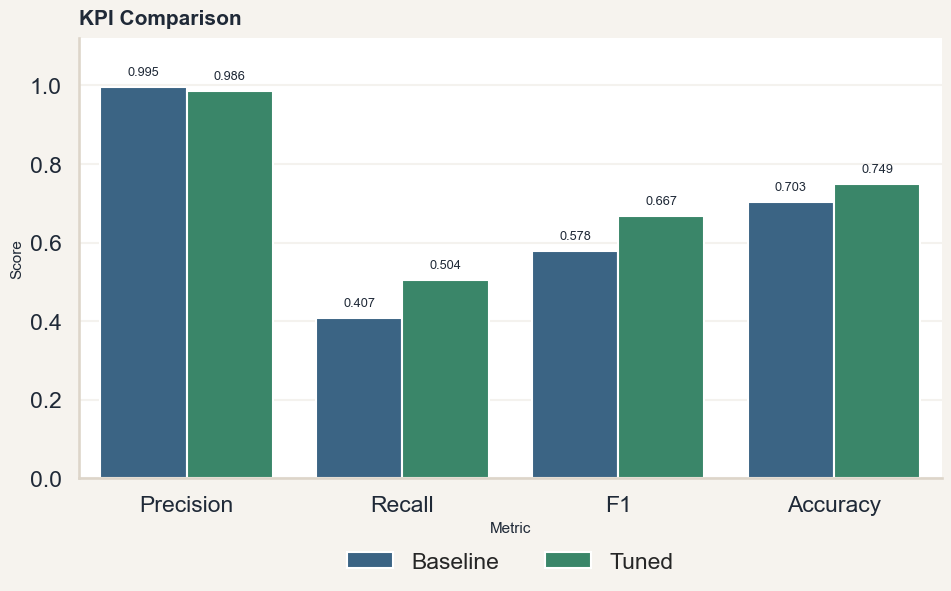

In [4]:
fig, ax = plt.subplots(figsize=(9.4, 5.8), facecolor=BG, constrained_layout=True)
sns.barplot(data=kpi_plot_df, x='Metric', y='Score', hue='Run', palette=[BLUE, GREEN], ax=ax)
ax.set_ylim(0, 1.12)
style_axis(ax, 'KPI Comparison', ylabel='Score')
ax.legend(frameon=False, title='', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
for container in ax.containers:
    label_bars(ax, container)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Tuned finds more real targets. That is the big win.
</div>


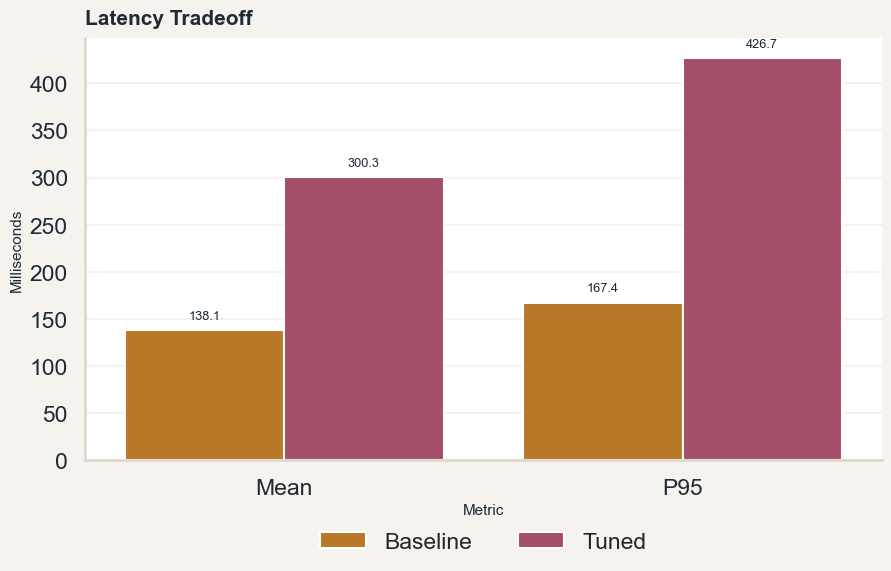

In [5]:
fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG, constrained_layout=True)
sns.barplot(data=latency_plot_df, x='Metric', y='Milliseconds', hue='Run', palette=[AMBER, RED], ax=ax)
style_axis(ax, 'Latency Tradeoff', ylabel='Milliseconds')
ax.legend(frameon=False, title='', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
for container in ax.containers:
    label_bars(ax, container, fmt='{:.1f}')
plt.show()


<div style="border-left: 6px solid #d17b0f; background: #fffaf2; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Tuned helps, but it is slower. So the gain is accuracy versus speed.
</div>


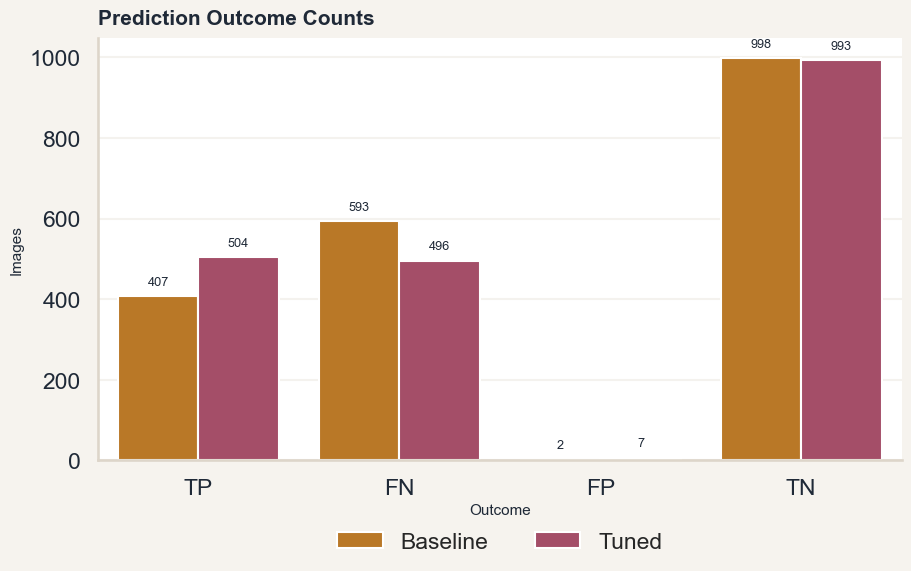

In [6]:
fig, ax = plt.subplots(figsize=(9.0, 5.6), facecolor=BG, constrained_layout=True)
sns.barplot(data=outcome_plot_df, x='Outcome', y='Count', hue='Run', order=['TP', 'FN', 'FP', 'TN'], palette=[AMBER, RED], ax=ax)
style_axis(ax, 'Prediction Outcome Counts', ylabel='Images')
ax.legend(frameon=False, title='', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
for container in ax.containers:
    label_bars(ax, container, fmt='{:.0f}')
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This is the easiest chart to explain. Tuned gets more true positives and fewer false negatives.
</div>


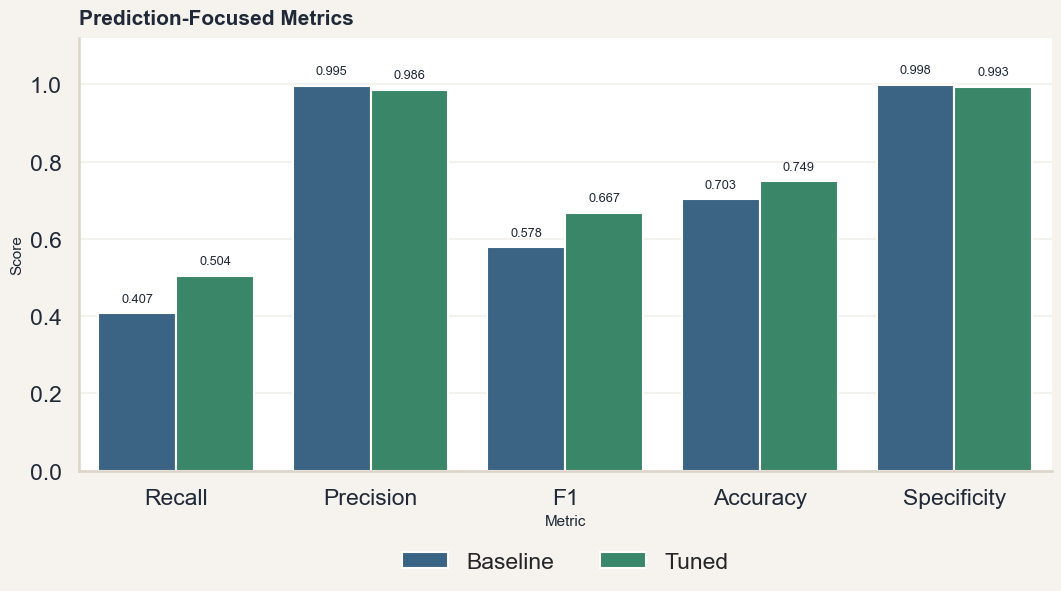

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 5.8), facecolor=BG, constrained_layout=True)
sns.barplot(
    data=prediction_metric_plot_df,
    x='Metric',
    y='Score',
    hue='Run',
    order=['Recall', 'Precision', 'F1', 'Accuracy', 'Specificity'],
    palette=[BLUE, GREEN],
    ax=ax,
)
ax.set_ylim(0, 1.12)
style_axis(ax, 'Prediction-Focused Metrics', ylabel='Score')
ax.legend(frameon=False, title='', loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
for container in ax.containers:
    label_bars(ax, container)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Recall is the star here. Precision drops a little, but it stays very high.
</div>


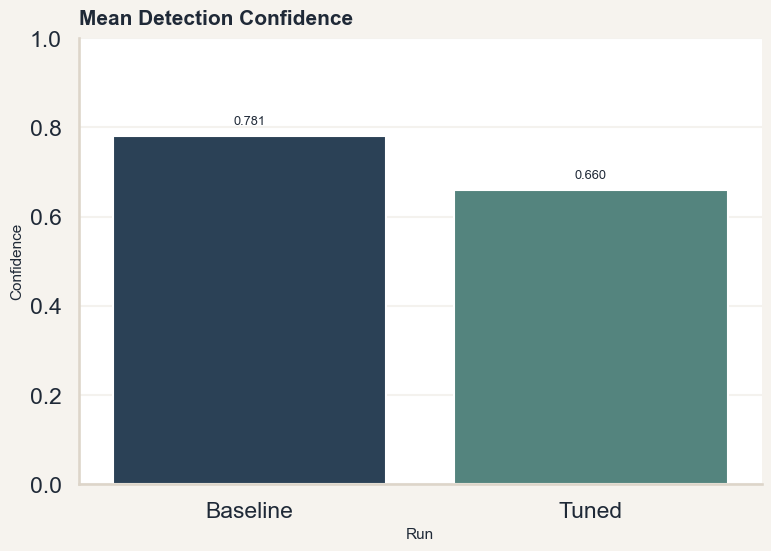

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 5.4), facecolor=BG, constrained_layout=True)
sns.barplot(data=confidence_plot_df, x='Run', y='Mean Detection Confidence', hue='Run', palette=[NAVY, TEAL], dodge=False, ax=ax)
ax.set_ylim(0, 1.0)
style_axis(ax, 'Mean Detection Confidence', ylabel='Confidence')
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for container in ax.containers:
    label_bars(ax, container)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Baseline is a bit more sure of itself. Tuned is a little less sure, but it finds more positives.
</div>


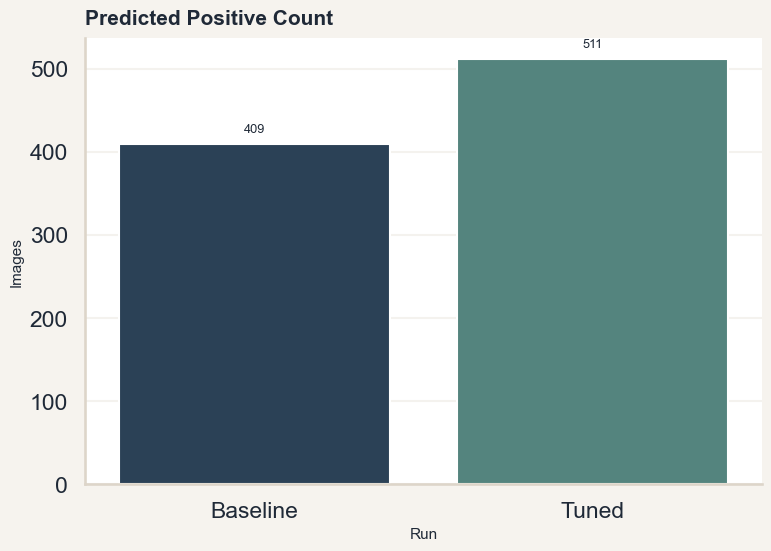

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 5.4), facecolor=BG, constrained_layout=True)
sns.barplot(data=positive_count_df, x='Run', y='Detected Positives', hue='Run', palette=[NAVY, TEAL], dodge=False, ax=ax)
style_axis(ax, 'Predicted Positive Count', ylabel='Images')
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for container in ax.containers:
    label_bars(ax, container, fmt='{:.0f}')
plt.show()


<div style="border-left: 6px solid #2d936c; background: #f8fff9; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Tuned says yes more often. That is why recall goes up.
</div>


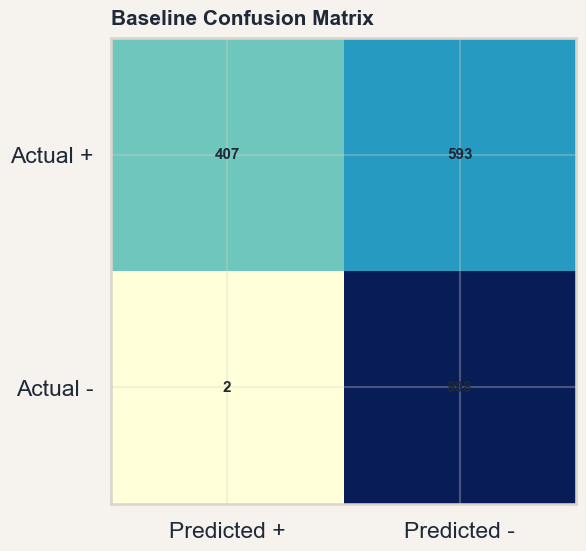

In [10]:
fig, ax = plt.subplots(figsize=(6.0, 5.4), facecolor=BG, constrained_layout=True)
draw_confusion(ax, baseline['aggregate']['confusion_matrix'], 'Baseline Confusion Matrix')
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
For baseline, the biggest problem is the false negatives. It misses many real targets.
</div>


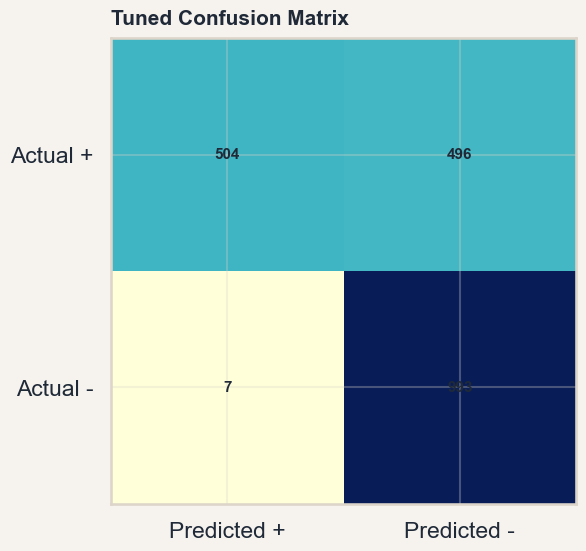

In [11]:
fig, ax = plt.subplots(figsize=(6.0, 5.4), facecolor=BG, constrained_layout=True)
draw_confusion(ax, tuned['aggregate']['confusion_matrix'], 'Tuned Confusion Matrix')
plt.show()


<div style="border-left: 6px solid #2d936c; background: #f8fff9; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Tuned cuts the misses down. That is the main reason the score improves.
</div>


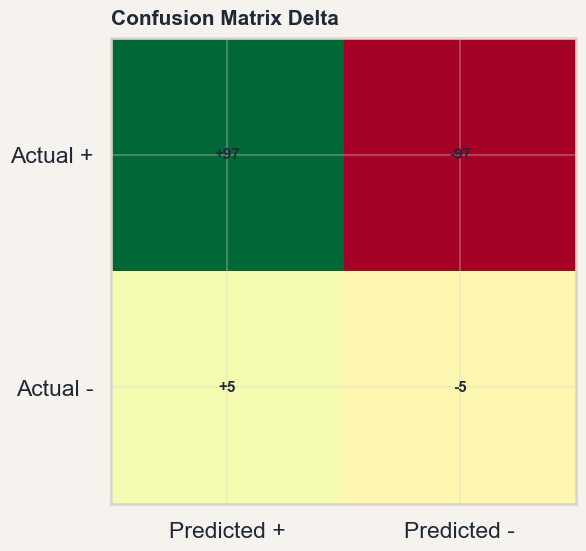

In [12]:
delta = confusion_matrix_from_dict(tuned['aggregate']['confusion_matrix']) - confusion_matrix_from_dict(baseline['aggregate']['confusion_matrix'])
fig, ax = plt.subplots(figsize=(6.0, 5.4), facecolor=BG, constrained_layout=True)
ax.imshow(delta, cmap='RdYlGn')
ax.set_title('Confusion Matrix Delta', loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted +', 'Predicted -'])
ax.set_yticklabels(['Actual +', 'Actual -'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{delta[i, j]:+d}', ha='center', va='center', fontsize=11, fontweight='bold', color=INK)
for spine in ax.spines.values():
    spine.set_color(GRID)
plt.show()


<div style="border-left: 6px solid #2d936c; background: #f8fff9; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Green means more. Red means less. Here, more true positives and fewer false negatives is what we want.
</div>


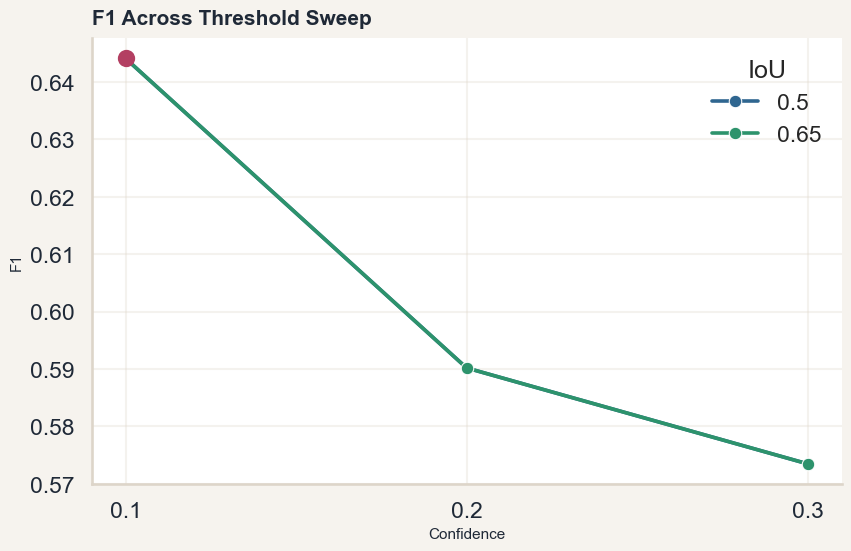

In [13]:
fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG, constrained_layout=True)
sns.lineplot(data=threshold_df, x='confidence', y='f1', hue='iou', marker='o', linewidth=2.6, palette=[BLUE, GREEN], ax=ax)
ax.scatter([best_threshold_df.iloc[0]['confidence']], [best_threshold_df.iloc[0]['f1']], color=RED, s=120, zorder=5)
style_axis(ax, 'F1 Across Threshold Sweep', ylabel='F1', xlabel='Confidence')
ax.set_xticks(sorted(threshold_df['confidence'].unique()))
leg = ax.get_legend()
if leg is not None:
    leg.set_title('IoU')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This says low confidence works best in this sweep. Higher confidence makes the model miss more.
</div>


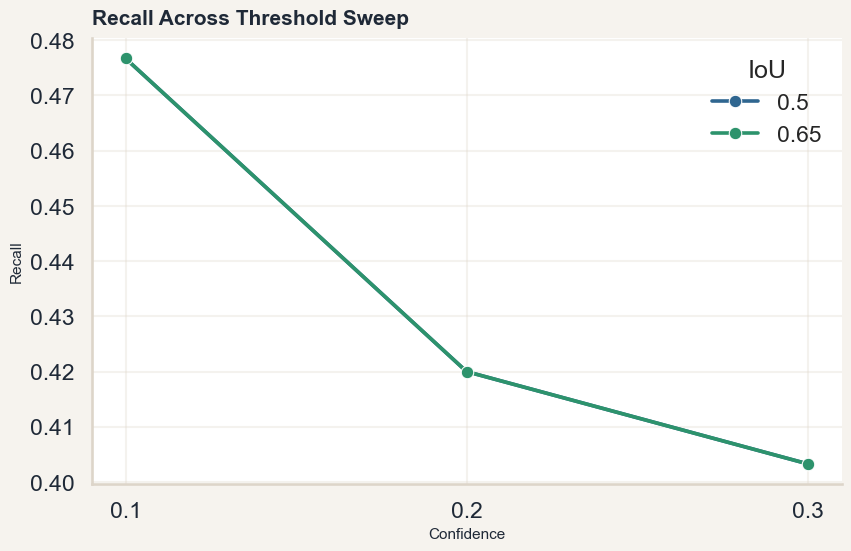

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG, constrained_layout=True)
sns.lineplot(data=threshold_df, x='confidence', y='recall', hue='iou', marker='o', linewidth=2.6, palette=[BLUE, GREEN], ax=ax)
style_axis(ax, 'Recall Across Threshold Sweep', ylabel='Recall', xlabel='Confidence')
ax.set_xticks(sorted(threshold_df['confidence'].unique()))
leg = ax.get_legend()
if leg is not None:
    leg.set_title('IoU')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Same story again. More confidence here means lower recall.
</div>


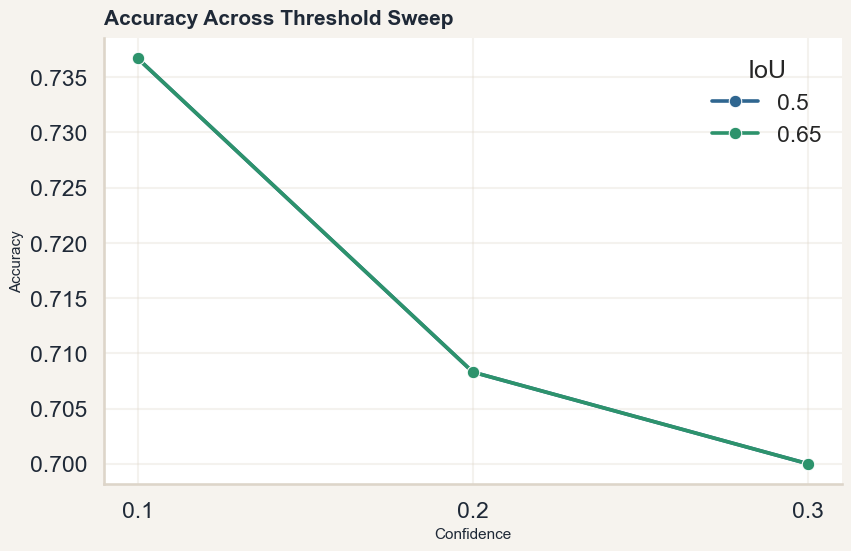

In [15]:
fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG, constrained_layout=True)
sns.lineplot(data=threshold_df, x='confidence', y='accuracy', hue='iou', marker='o', linewidth=2.6, palette=[BLUE, GREEN], ax=ax)
style_axis(ax, 'Accuracy Across Threshold Sweep', ylabel='Accuracy', xlabel='Confidence')
ax.set_xticks(sorted(threshold_df['confidence'].unique()))
leg = ax.get_legend()
if leg is not None:
    leg.set_title('IoU')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #d17b0f; background: #fffaf2; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Accuracy also gets worse when confidence goes up in this small sweep.
</div>


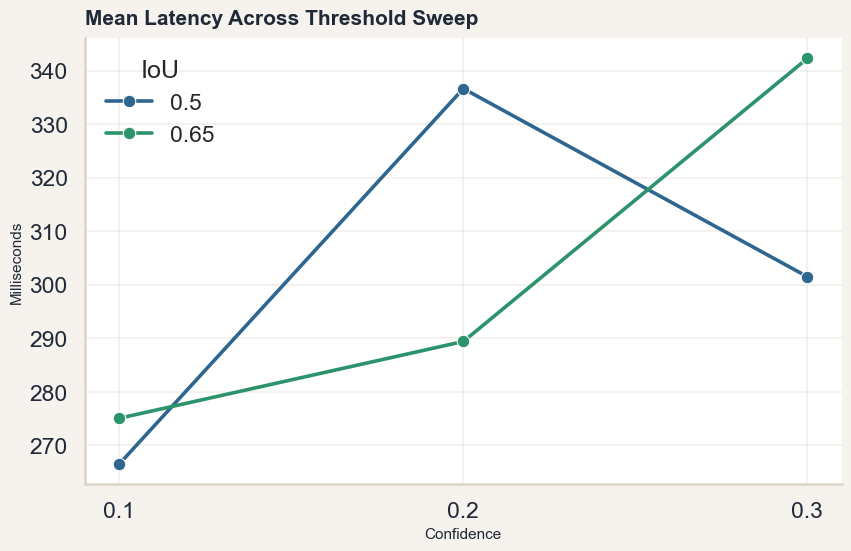

In [16]:
fig, ax = plt.subplots(figsize=(8.4, 5.4), facecolor=BG, constrained_layout=True)
sns.lineplot(data=threshold_df, x='confidence', y='mean latency (ms)', hue='iou', marker='o', linewidth=2.6, palette=[BLUE, GREEN], ax=ax)
style_axis(ax, 'Mean Latency Across Threshold Sweep', ylabel='Milliseconds', xlabel='Confidence')
ax.set_xticks(sorted(threshold_df['confidence'].unique()))
leg = ax.get_legend()
if leg is not None:
    leg.set_title('IoU')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #d17b0f; background: #fffaf2; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This one is about cost. Even when scores change, latency stays an important tradeoff.
</div>


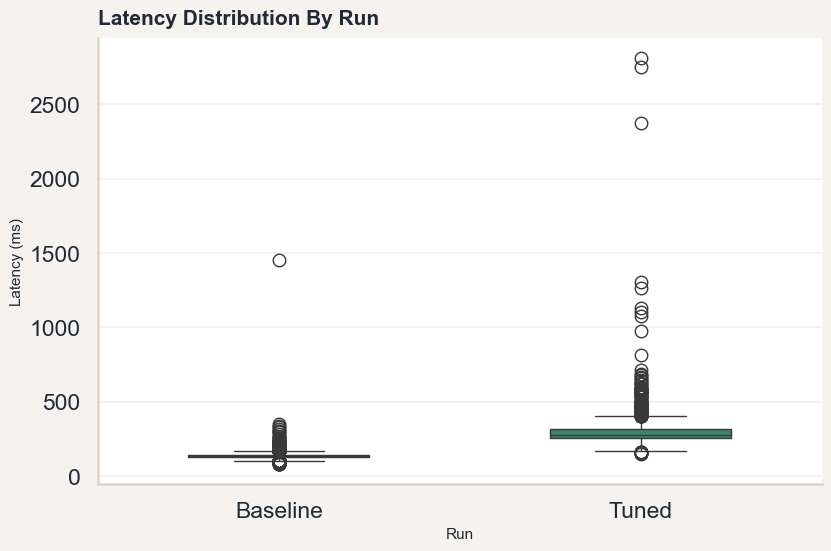

In [17]:
fig, ax = plt.subplots(figsize=(8.2, 5.4), facecolor=BG, constrained_layout=True)
sns.boxplot(data=details_df, x='Run', y='Latency (ms)', hue='Run', palette=[BLUE, GREEN], dodge=False, width=0.5, ax=ax)
style_axis(ax, 'Latency Distribution By Run', ylabel='Latency (ms)')
leg = ax.get_legend()
if leg is not None:
    leg.remove()
plt.show()


<div style="border-left: 6px solid #d17b0f; background: #fffaf2; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
The whole tuned box sits higher. So tuned is slower on a lot of images, not just on the average.
</div>


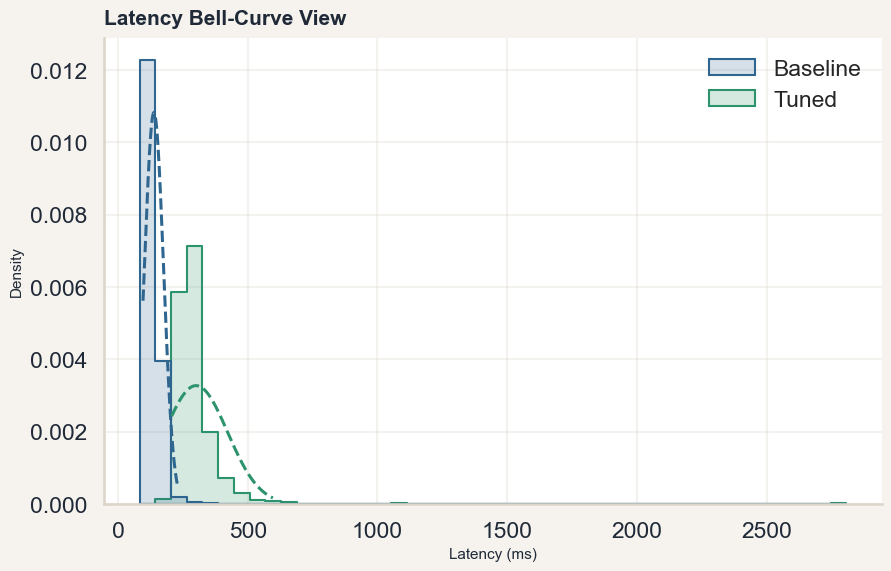

In [18]:
fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG, constrained_layout=True)
sns.histplot(data=details_df, x='Latency (ms)', hue='Run', stat='density', common_norm=False, bins=45, element='step', fill=True, alpha=0.20, palette=[BLUE, GREEN], ax=ax)
for run_name, color in {'Baseline': BLUE, 'Tuned': GREEN}.items():
    values = details_df.loc[details_df['Run'] == run_name, 'Latency (ms)'].dropna().astype(float)
    mu = values.mean()
    sigma = values.std(ddof=0)
    xs = np.linspace(values.quantile(0.01), values.quantile(0.99), 300)
    ax.plot(xs, gaussian_pdf(xs, mu, sigma), color=color, linestyle='--', linewidth=2.2)
style_axis(ax, 'Latency Bell-Curve View', ylabel='Density', xlabel='Latency (ms)')
leg = ax.get_legend()
if leg is not None:
    leg.set_title('')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #2d936c; background: #f8fff9; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
The dashed line is the simple bell-curve look. If green is more to the right, tuned is slower.
</div>


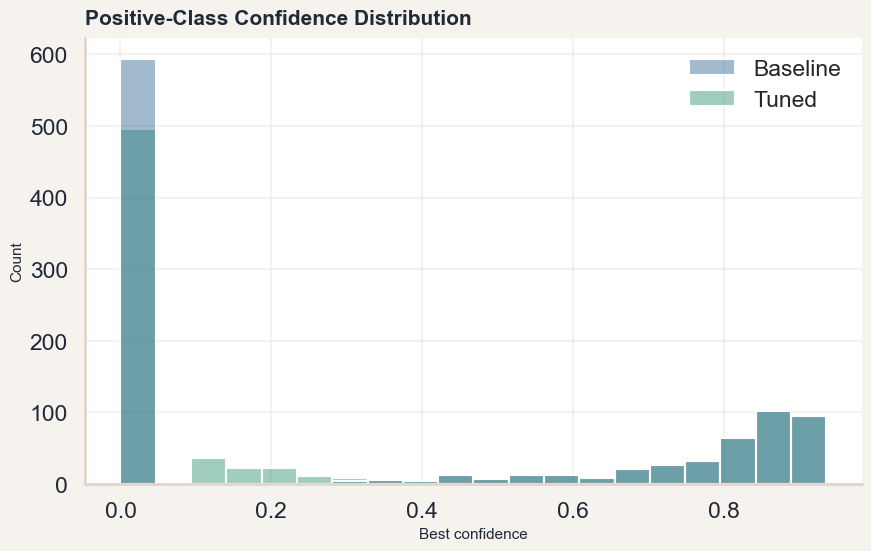

In [19]:
fig, ax = plt.subplots(figsize=(8.6, 5.4), facecolor=BG, constrained_layout=True)
sns.histplot(data=positive_conf_df, x='Best Confidence', hue='Run', bins=20, palette=[BLUE, GREEN], alpha=0.45, element='bars', stat='count', common_norm=False, ax=ax)
style_axis(ax, 'Positive-Class Confidence Distribution', ylabel='Count', xlabel='Best confidence')
leg = ax.get_legend()
if leg is not None:
    leg.set_title('')
    leg.set_frame_on(False)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This only looks at real positive examples. It shows how strong the model scores the targets we care about.
</div>


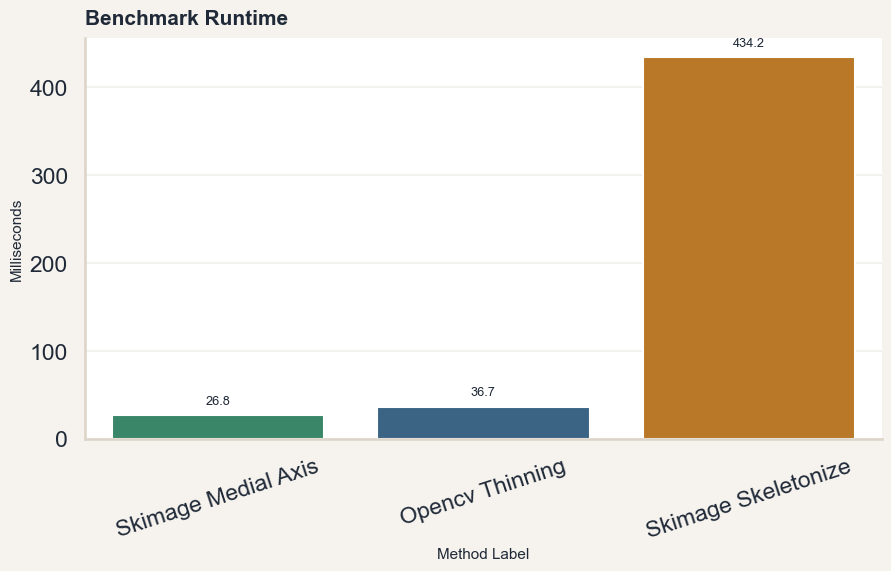

In [20]:
palette = [GREEN, BLUE, AMBER, RED, TEAL, NAVY]
fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG, constrained_layout=True)
sns.barplot(data=benchmark_df, x='Method Label', y='Runtime (ms)', hue='Method Label', palette=palette[:len(benchmark_df)], dodge=False, ax=ax)
style_axis(ax, 'Benchmark Runtime', ylabel='Milliseconds')
ax.tick_params(axis='x', rotation=18)
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for container in ax.containers:
    label_bars(ax, container, fmt='{:.1f}')
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
For the drone benchmark, speed is the biggest separator.
</div>


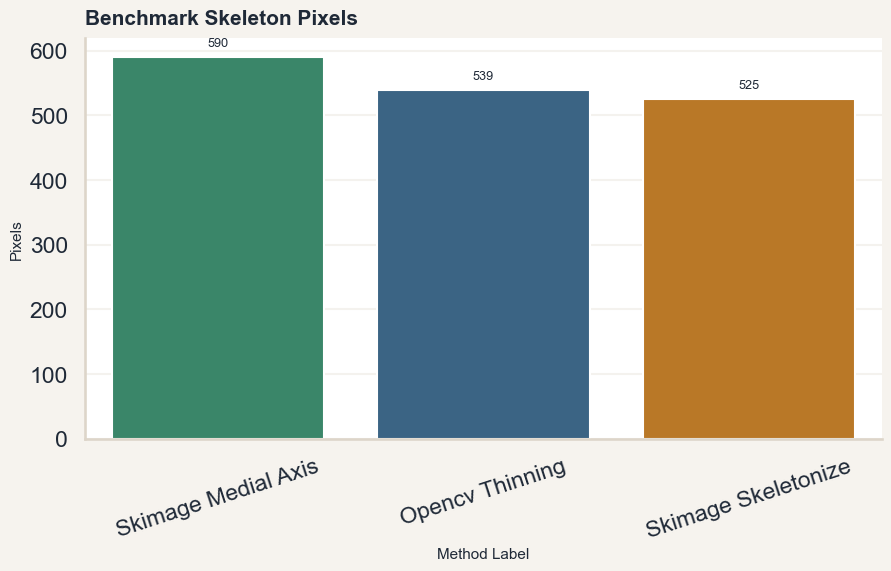

In [21]:
palette = [GREEN, BLUE, AMBER, RED, TEAL, NAVY]
fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG, constrained_layout=True)
sns.barplot(data=benchmark_df, x='Method Label', y='Skeleton Pixels', hue='Method Label', palette=palette[:len(benchmark_df)], dodge=False, ax=ax)
style_axis(ax, 'Benchmark Skeleton Pixels', ylabel='Pixels')
ax.tick_params(axis='x', rotation=18)
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for container in ax.containers:
    label_bars(ax, container, fmt='{:.0f}')
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
These pixel counts are fairly close. So the main visual difference is not huge density change.
</div>


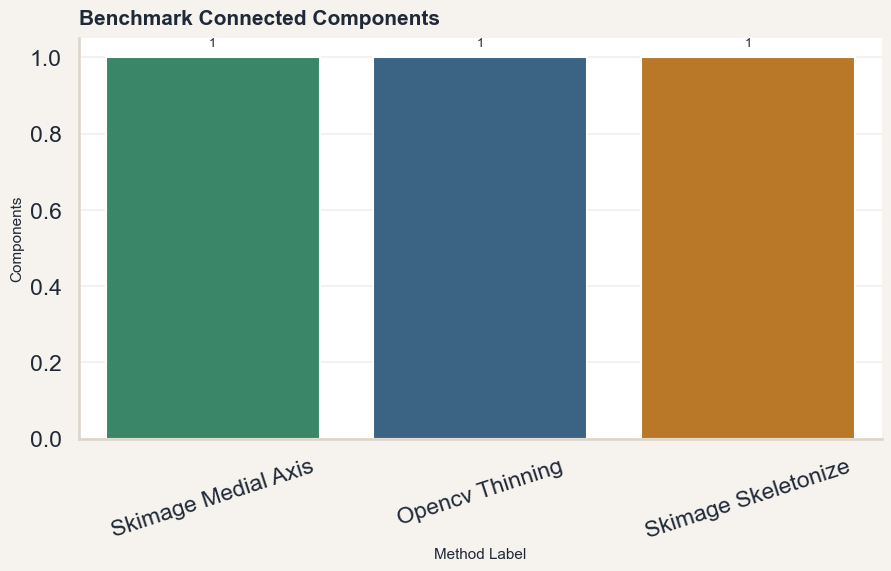

In [22]:
palette = [GREEN, BLUE, AMBER, RED, TEAL, NAVY]
fig, ax = plt.subplots(figsize=(8.8, 5.6), facecolor=BG, constrained_layout=True)
sns.barplot(data=benchmark_df, x='Method Label', y='Connected Components', hue='Method Label', palette=palette[:len(benchmark_df)], dodge=False, ax=ax)
style_axis(ax, 'Benchmark Connected Components', ylabel='Components')
ax.tick_params(axis='x', rotation=18)
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for container in ax.containers:
    label_bars(ax, container, fmt='{:.0f}')
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Lower is better here because fewer pieces means a more connected skeleton.
</div>


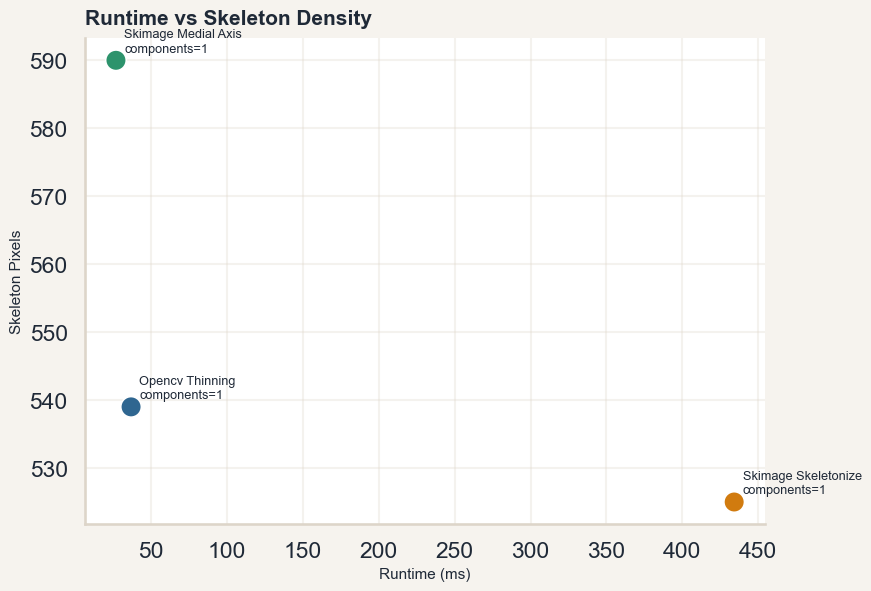

In [23]:
palette = [GREEN, BLUE, AMBER, RED, TEAL, NAVY]
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
sns.scatterplot(
    data=benchmark_df,
    x='Runtime (ms)',
    y='Skeleton Pixels',
    hue='Method Label',
    size='Connected Components',
    sizes=(220, 220),
    palette=palette[:len(benchmark_df)],
    ax=ax,
)
style_axis(ax, 'Runtime vs Skeleton Density', ylabel='Skeleton Pixels', xlabel='Runtime (ms)')
leg = ax.get_legend()
if leg is not None:
    leg.remove()
for method_label, runtime_ms, skeleton_pixels, components in benchmark_df[['Method Label', 'Runtime (ms)', 'Skeleton Pixels', 'Connected Components']].itertuples(index=False, name=None):
    ax.annotate(f'{method_label}\ncomponents={int(components)}', (runtime_ms, skeleton_pixels), xytext=(6, 6), textcoords='offset points', fontsize=9.2, color=INK)
plt.show()


<div style="border-left: 6px solid #2d936c; background: #f8fff9; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
Left means faster. Higher means more skeleton pixels. This helps compare speed and shape in one look.
</div>


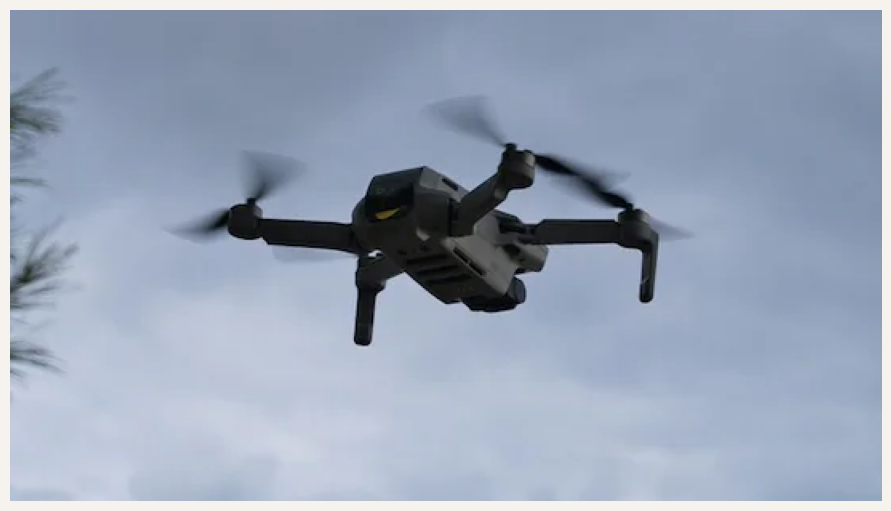

In [24]:
fig, ax = plt.subplots(figsize=(8.8, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
plain_image = plt.imread(plain_drone_image)
ax.imshow(plain_image, cmap='gray' if plain_image.ndim == 2 else None)
plt.show()


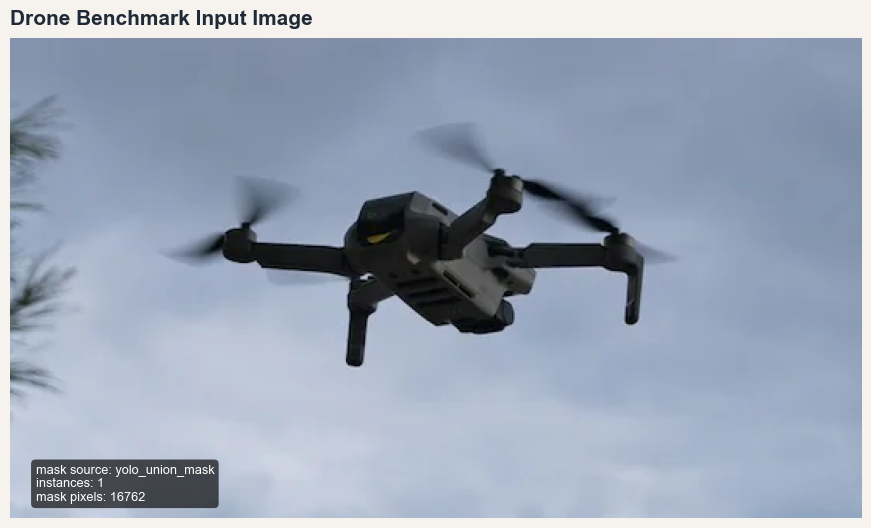

In [25]:
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
image = plt.imread(active_benchmark_image)
ax.imshow(image, cmap='gray' if image.ndim == 2 else None)
ax.set_title('Drone Benchmark Input Image', loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.text(
    0.03,
    0.03,
    f"mask source: {benchmark['mask_source']}\ninstances: {benchmark['yolo_instances_detected']}\nmask pixels: {benchmark['mask_pixels']}",
    transform=ax.transAxes,
    fontsize=9.2,
    color='white',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='black', alpha=0.65, edgecolor='none'),
)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This is the input image for the skeleton benchmark. If you save `presentation_drone_input.png` or `presentation_drone_input.jpg` in the repo root, this cell will use that file.
</div>


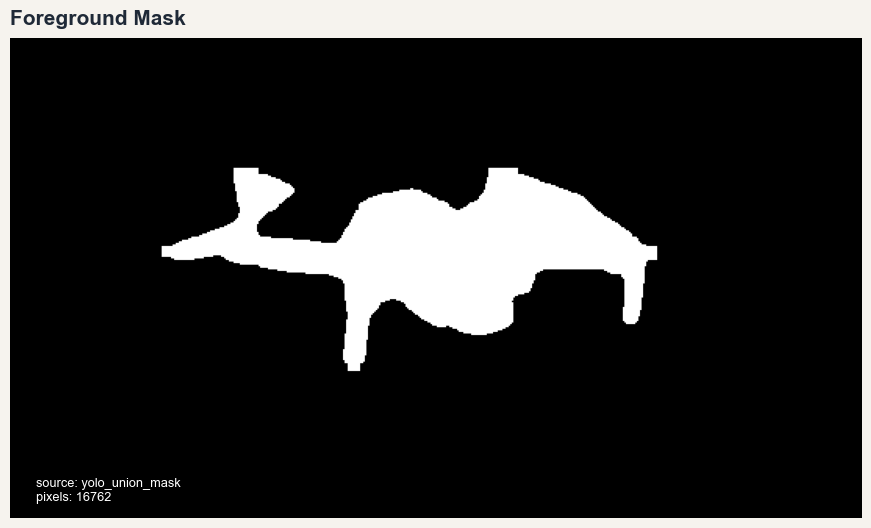

In [26]:
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
mask_image = plt.imread(resolve_asset(benchmark_mask_path))
ax.imshow(mask_image, cmap='gray' if mask_image.ndim == 2 else None)
ax.set_title('Foreground Mask', loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.text(
    0.03,
    0.03,
    f"source: {benchmark['mask_source']}\npixels: {benchmark['mask_pixels']}",
    transform=ax.transAxes,
    fontsize=9.2,
    color='white',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='black', alpha=0.65, edgecolor='none'),
)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This is the mask used before skeletonization. White is the part the methods turn into a skeleton.
</div>


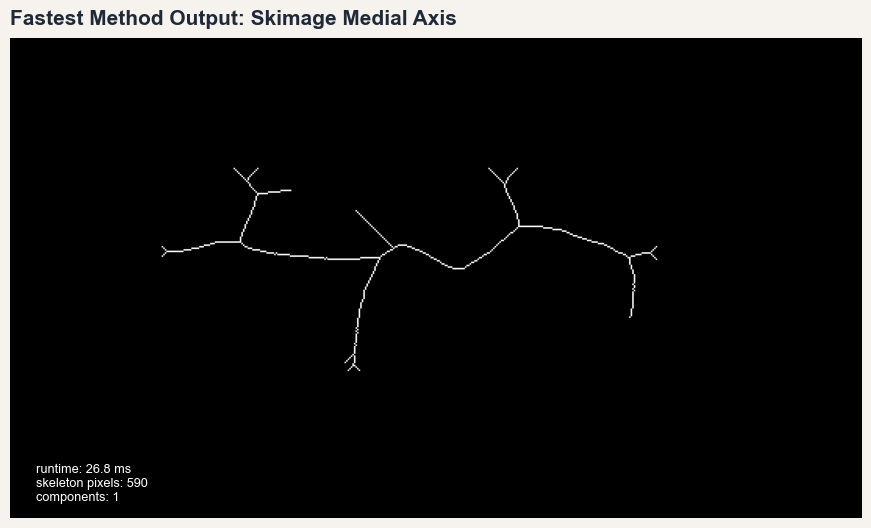

In [27]:
row = benchmark_df.iloc[0]
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
output_image = plt.imread(resolve_asset(row['Output Path']))
ax.imshow(output_image, cmap='gray' if output_image.ndim == 2 else None)
ax.set_title('Fastest Method Output: ' + row['Method Label'], loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.text(
    0.03,
    0.03,
    f"runtime: {row['Runtime (ms)']:.1f} ms\nskeleton pixels: {int(row['Skeleton Pixels'])}\ncomponents: {int(row['Connected Components'])}",
    transform=ax.transAxes,
    fontsize=9.2,
    color='white',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='black', alpha=0.65, edgecolor='none'),
)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This is the fastest method output.
</div>


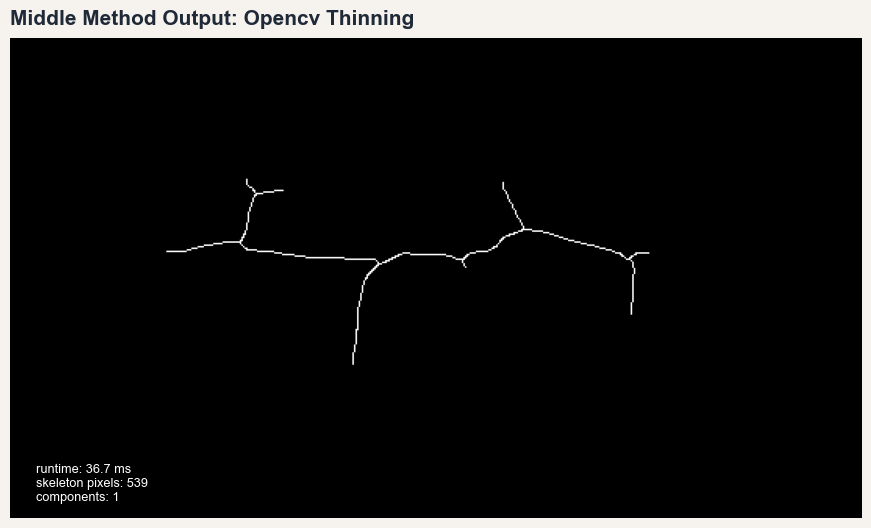

In [28]:
row = benchmark_df.iloc[1]
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
output_image = plt.imread(resolve_asset(row['Output Path']))
ax.imshow(output_image, cmap='gray' if output_image.ndim == 2 else None)
ax.set_title('Middle Method Output: ' + row['Method Label'], loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.text(
    0.03,
    0.03,
    f"runtime: {row['Runtime (ms)']:.1f} ms\nskeleton pixels: {int(row['Skeleton Pixels'])}\ncomponents: {int(row['Connected Components'])}",
    transform=ax.transAxes,
    fontsize=9.2,
    color='white',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='black', alpha=0.65, edgecolor='none'),
)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This one is another tradeoff point between speed and shape.
</div>


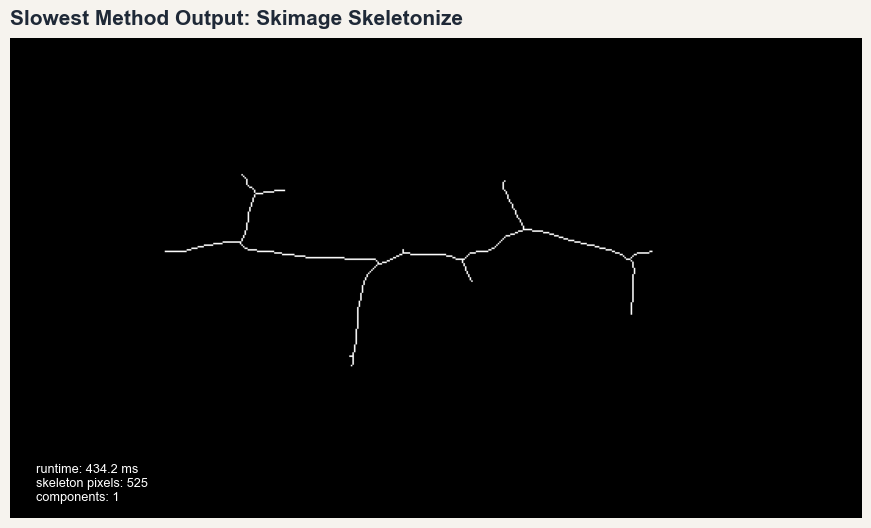

In [29]:
row = benchmark_df.iloc[2]
fig, ax = plt.subplots(figsize=(8.6, 5.8), facecolor=BG, constrained_layout=True)
ax.axis('off')
output_image = plt.imread(resolve_asset(row['Output Path']))
ax.imshow(output_image, cmap='gray' if output_image.ndim == 2 else None)
ax.set_title('Slowest Method Output: ' + row['Method Label'], loc='left', fontsize=15, fontweight='bold', color=INK, pad=10)
ax.text(
    0.03,
    0.03,
    f"runtime: {row['Runtime (ms)']:.1f} ms\nskeleton pixels: {int(row['Skeleton Pixels'])}\ncomponents: {int(row['Connected Components'])}",
    transform=ax.transAxes,
    fontsize=9.2,
    color='white',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='black', alpha=0.65, edgecolor='none'),
)
plt.show()


<div style="border-left: 6px solid #2f6690; background: #f7fbff; padding: 12px 16px; border-radius: 10px; margin: 6px 0;">
<b>Simple meaning.</b><br>
This is the slowest method output.
</div>
